Project Python Foundations: FoodHub Data Analysis

Start by importing the required libraries

In [ ]:
# import libraries for data manipulationimport numpy as npimport pandas as pd# import libraries for data visualizationimport matplotlib.pyplot as pltimport seaborn as sns# to restrict the float value to 3 decimal placespd.set_option('display.float_format', lambda x: '%.3f' % x)

In [ ]:
from google.colab import drivedrive.mount('/content/drive')

Mounted at /content/drive

Understanding the structure of the data

---



---



In [ ]:
# read the datadf = pd.read_csv('/content/drive/MyDrive/Python_Course/foodhub_order.csv')# returns the first 5 rowsdf.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.750,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.080,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.230,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.200,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.590,Weekday,4,25,24


Observations:The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

How many rows and columns are present in the data?

In [ ]:
df.shape

(1898, 9)

Observations:There are 1898 rows and 9 columns in dataset.

What are the datatypes of the different columns in the dataset? (The info() function can be used)

In [ ]:
# Use info() to print a concise summary of the DataFramedf.info()

<class 'pandas.core.frame.DataFrame'>RangeIndex: 1898 entries, 0 to 1897Data columns (total 9 columns): #   Column                 Non-Null Count  Dtype  ---  ------                 --------------  -----   0   order_id               1898 non-null   int64   1   customer_id            1898 non-null   int64   2   restaurant_name        1898 non-null   object  3   cuisine_type           1898 non-null   object  4   cost_of_the_order      1898 non-null   float64 5   day_of_the_week        1898 non-null   object  6   rating                 1898 non-null   object  7   food_preparation_time  1898 non-null   int64   8   delivery_time          1898 non-null   int64  dtypes: float64(1), int64(4), object(4)memory usage: 133.6+ KB

Observations:All the columns have 1898 observations indicating that there are no null values in them.The rating is being read as a 'object' data type but it should be in numerical format.The restaurant_name,cuisine_type,day_of_the_week,rating are of object type while the rest of the columns are numerical in nature.The object type columns contain categories in them

Are there any missing values in the data? If yes, treat them using an appropriate method.

In [ ]:
df.isnull().sum()

order_id                 0customer_id              0restaurant_name          0cuisine_type             0cost_of_the_order        0day_of_the_week          0rating                   0food_preparation_time    0delivery_time            0dtype: int64

Observations: There are no missing values in data.

Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed?

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.000,1477495.500,548.050,1476547.000,1477021.250,1477495.500,1477969.750,1478444.000
customer_id,1898.000,171168.478,113698.140,1311.000,77787.750,128600.000,270525.000,405334.000
cost_of_the_order,1898.000,16.499,7.484,4.470,12.080,14.140,22.297,35.410
food_preparation_time,1898.000,27.372,4.632,20.000,23.000,27.000,31.000,35.000
delivery_time,1898.000,24.162,4.973,15.000,20.000,25.000,28.000,33.000


Observations:Observations on Food preparation time:
* Minimun Time : 20 minutes
* Maximum Time : 35 minutes
* Average Time : 27.372minutes

How many orders are not rated?

In [ ]:
df.rating.unique()

array(['Not given', '5', '3', '4'], dtype=object)

In [ ]:
df.rating.value_counts()

Not given    7365            5884            3863            188Name: rating, dtype: int64

Observations:There are 736 orders that are not rated.

Exploratory Data Analysis (EDA)

Univariate Analysis

Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.)

In [ ]:
order_id_arr=df['order_id'].unique()Num_unique_ids=df['order_id'].nunique()print('order_id_array=', order_id_arr)print('Num of unique ids=',Num_unique_ids)

order_id_array= [1477147 1477685 1477070 ... 1477819 1477513 1478056]Num of unique ids= 1898

In [ ]:
order_id_arr=df['customer_id'].unique()Num_unique_ids=df['customer_id'].nunique()print('customer_id_array=', order_id_arr)print('Num of unique ids=',Num_unique_ids)

customer_id_array= [337525 358141  66393 ...  97838 292602 397537]Num of unique ids= 1200

In [ ]:
#order_id_arr=df['restaurant_name'].unique()Num_unique_ids=df['restaurant_name'].nunique()#print('restaurant_name=', order_id_arr)print('Num of restaurants=',Num_unique_ids)

Num of restaurants= 178

In [ ]:
cuisine_type_arr=df['cuisine_type'].unique()Num_cuisine_type=df['cuisine_type'].nunique()print('cuisine_type=',cuisine_type_arr)print('Num of cuisine_types=',Num_cuisine_type)

cuisine_type= ['Korean' 'Japanese' 'Mexican' 'American' 'Indian' 'Italian' 'Mediterranean' 'Chinese' 'Middle Eastern' 'Thai' 'Southern' 'French' 'Spanish' 'Vietnamese']Num of cuisine_types= 14

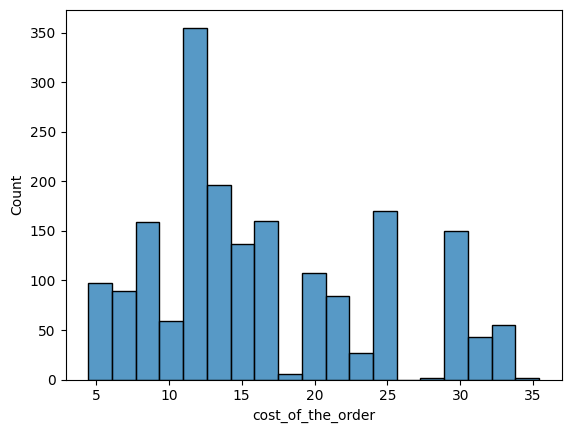

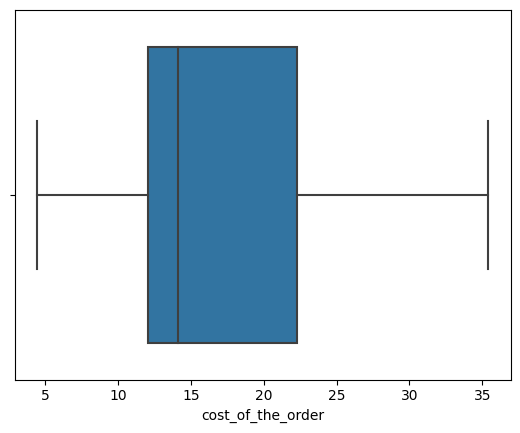

In [ ]:
sns.histplot(data=df,x='cost_of_the_order')plt.show()sns.boxplot(data=df,x='cost_of_the_order')plt.show()

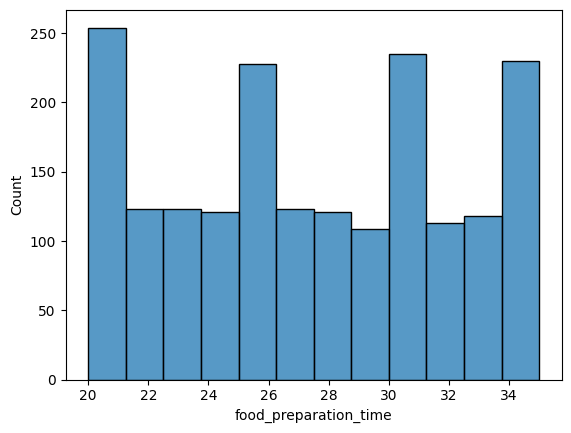

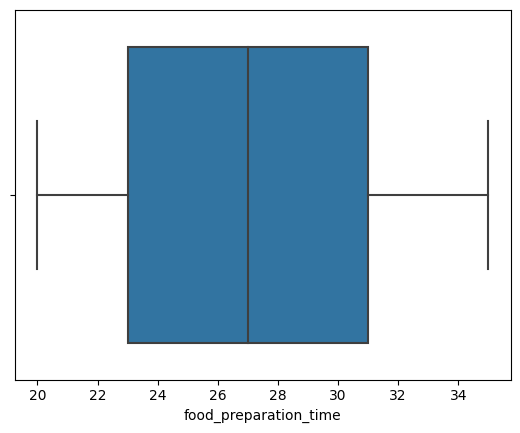

In [ ]:
sns.histplot(data=df,x='food_preparation_time')plt.show()sns.boxplot(data=df,x='food_preparation_time')plt.show()

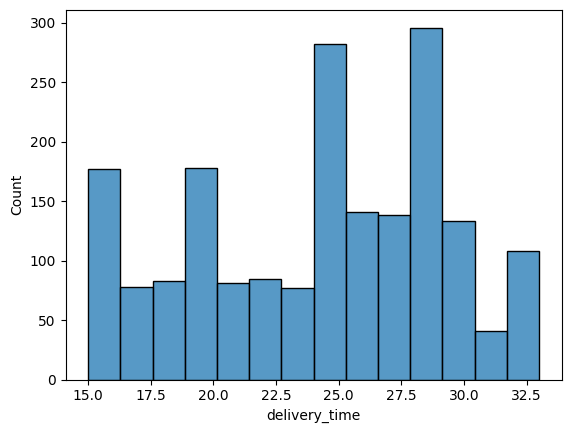

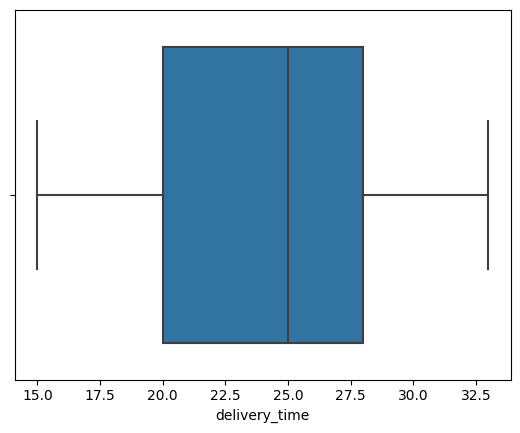

In [ ]:
sns.histplot(data=df,x='delivery_time')plt.show()sns.boxplot(data=df,x='delivery_time')plt.show()

Observation: Cost of the order is right skewed, food preparation time and delivery time is normally distributed with no outliers.

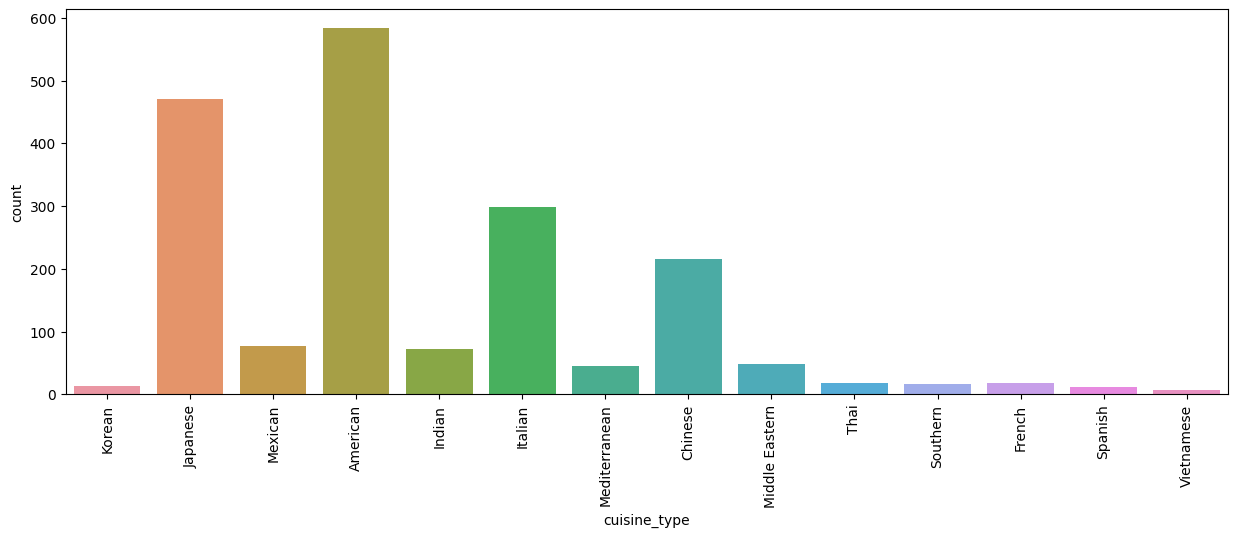

In [ ]:
plt.figure(figsize = (15,5))sns.countplot(data=df,x='cuisine_type')plt.xticks(rotation=90)plt.show()

Observation : American Cuisine type is the bestseller among all the cuisines.

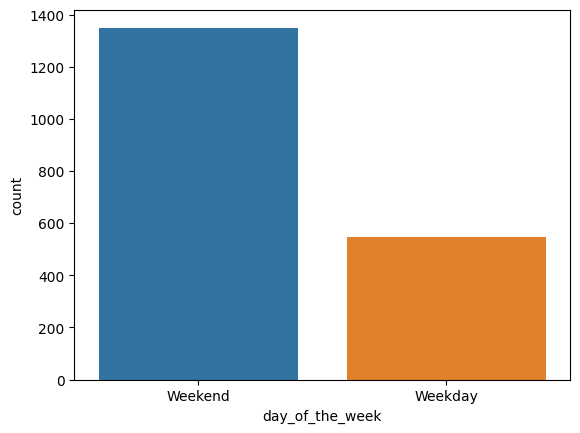

In [ ]:
sns.countplot(data=df,x='day_of_the_week')plt.show()

Observation :Most number of orders are received on weekends.

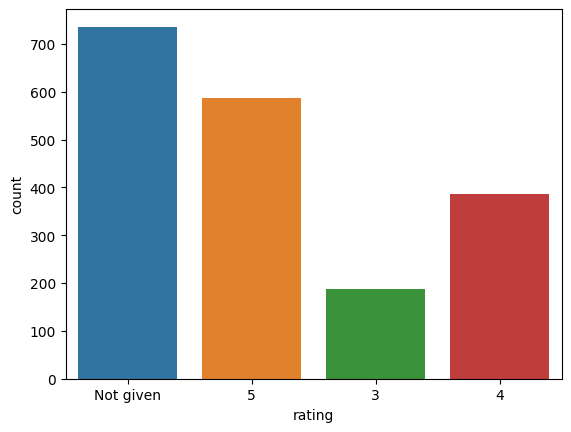

In [ ]:
sns.countplot(data=df,x='rating')plt.show()

Observation :600 restaurants are rated 5 and 700 restaurants are not given any rating,

Question 7: Which are the top 5 restaurants in terms of the number of orders received?

In [ ]:
df_rest=df.restaurant_name.value_counts(normalize=False,sort=True,)df_rest.head(5)

Shake Shack                  219The Meatball Shop            132Blue Ribbon Sushi            119Blue Ribbon Fried Chicken     96Parm                          68Name: restaurant_name, dtype: int64

Observations: The top 5 restaurants in terms pf the orders received are
* 1.ShakeShack
* 2.The Meatball shop
* 3.Blue Ribbon Sushi
* 4.Blue Ribbon Fried chicken
* 5.Parm

Which is the most popular cuisine on weekends?

In [ ]:
#df.cuisine_type.value_counts(sort=True)#df.day_of_the_week.value_counts()df_new=df.loc[df['day_of_the_week']=='Weekend']df_new.cuisine_type.value_counts()

American          415Japanese          335Italian           207Chinese           163Mexican            53Indian             49Mediterranean      32Middle Eastern     32Thai               15French             13Korean             11Southern           11Spanish            11Vietnamese          4Name: cuisine_type, dtype: int64

Observations: American is the most popular cuisine on weekends.

What percentage of the orders cost more than 20 dollars?

In [ ]:
#int total_rows;Rows=df['cost_of_the_order'].count()print ('Total_orders=', Rows);Above_20_orders=df['cost_of_the_order'][df['cost_of_the_order']>20].count()print ('Total_orders=', Above_20_orders);Percentage=(Above_20_orders/Rows)*100Rounded_page=round(Percentage,2)print ('Orders more than 20 dollars=', Rounded_page,'%')

Total_orders= 1898Total_orders= 555Orders more than 20 dollars= 29.24 %

The percentage of orders more than 20dollars is 29.24%

What is the mean order delivery time?

In [ ]:
Mean_order=df['delivery_time'].mean()rounded_mean=round(Mean_order,2)print('Mean_order_delivery_time=',rounded_mean)

Mean_order_delivery_time= 24.16

The mean order delivery time is 24.16 minutes.

The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed.

In [ ]:
top_3_custs=[df['customer_id'].value_counts(normalize=False).head(3)]print('Top 3 customers and orders', top_3_custs)df[['order_id','customer_id']].groupby('customer_id').count().sort_values(by='order_id',axis=0,ascending=False).head(3)#df[['order_id','customer_id']].groupby('customer_id').count().sort_values(by = 'order_id',axis = 0, ascending=False).head(3)

Top 3 customers and orders [52832    1347440    1083287     9Name: customer_id, dtype: int64]

,order_id
customer_id,
52832,13
47440,10
83287,9


Top 3 customer_ids are 52832,47440,83287 and their respective orders are 13,10 and 9.

Multivariate Analysis

Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables)

<ipython-input-25-b547eaa8dce0>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.  sns.heatmap(df.corr(),annot=True,cmap='Spectral',vmin=-1,vmax=1)

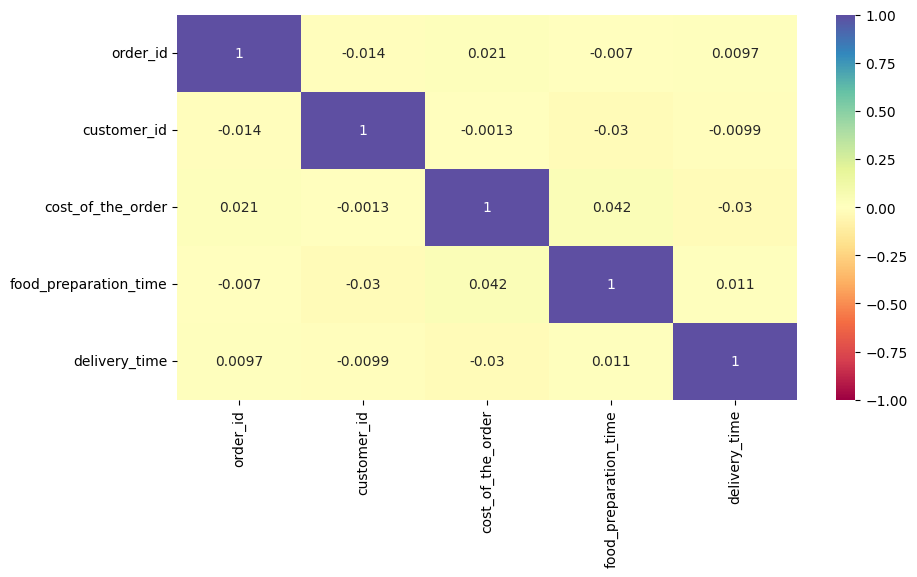

In [ ]:
plt.figure(figsize=(10,5))sns.heatmap(df.corr(),annot=True,cmap='Spectral',vmin=-1,vmax=1)plt.show()

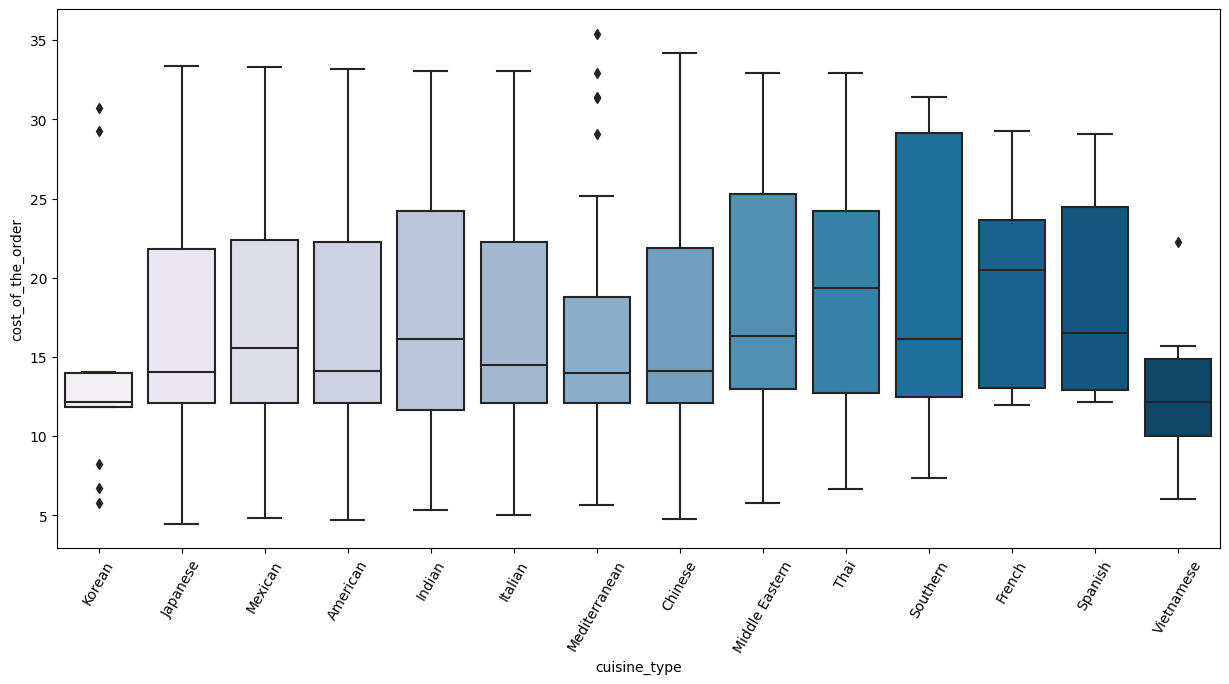

In [ ]:
# Relationship between cost of the order and cuisine typeplt.figure(figsize=(15,7))sns.boxplot(x = "cuisine_type", y = "cost_of_the_order", data = df, palette = 'PuBu')plt.xticks(rotation = 60)plt.show()

Observation: For any cuisine the range of cost of order is between 10 to 20dollars

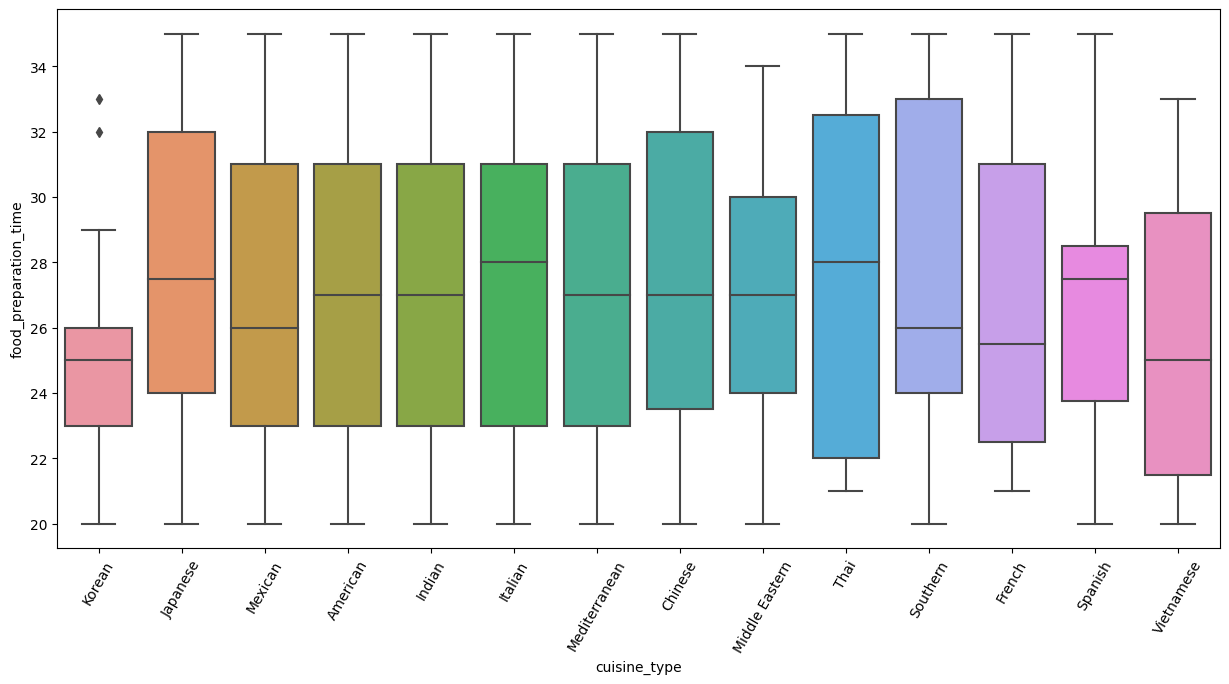

In [ ]:
# Relationship between food preparation time and cuisine typeplt.figure(figsize=(15,7))sns.boxplot(x='cuisine_type',y='food_preparation_time',data=df)plt.xticks(rotation = 60)plt.show()

Observation: Cuisine type and food preparation time has no correlation.

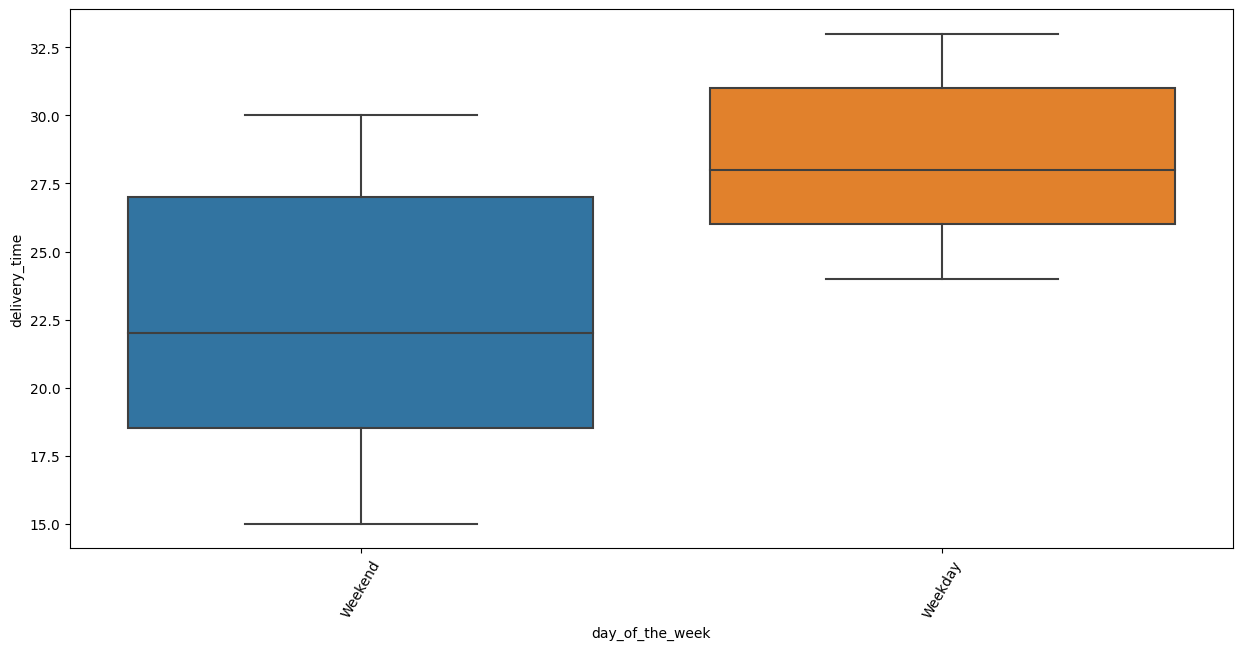

In [ ]:
# Relationship between day of the week and delivery timeplt.figure(figsize=(15,7))sns.boxplot(x = "day_of_the_week", y = "delivery_time", data = df)plt.xticks(rotation = 60)plt.show()

Observation: Average Food delivery time on weekdays is almost 5 mins more than Average food delivery time on weekends

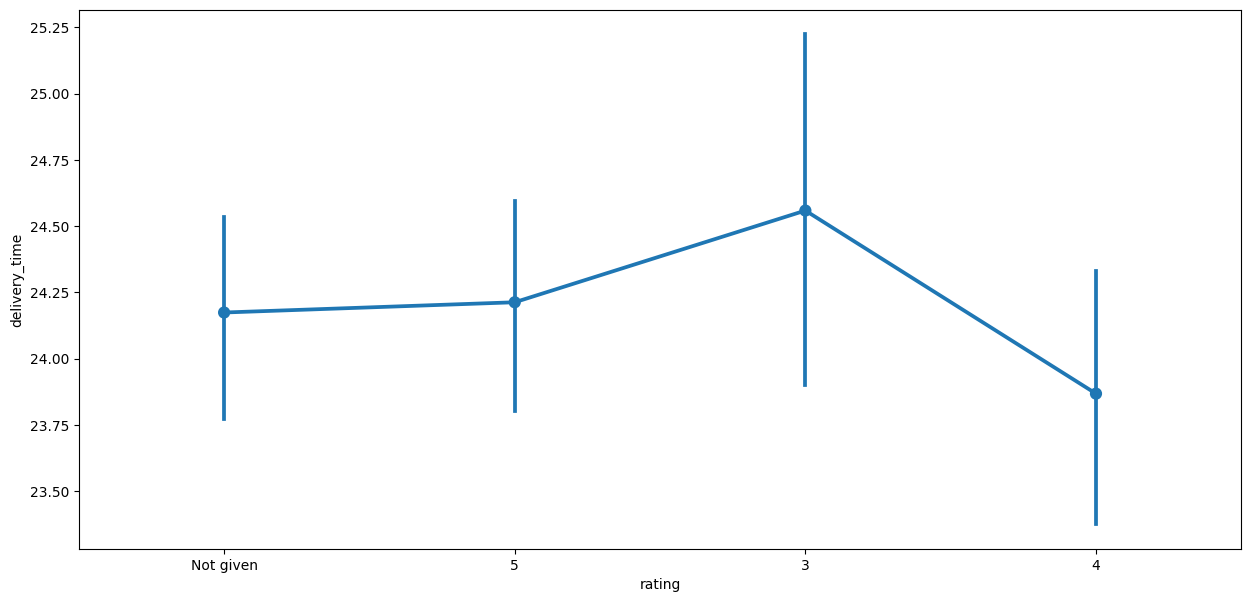

In [ ]:
# Relationship between rating and delivery timeplt.figure(figsize=(15, 7))sns.pointplot(x = 'rating', y = 'delivery_time', data = df)plt.show()

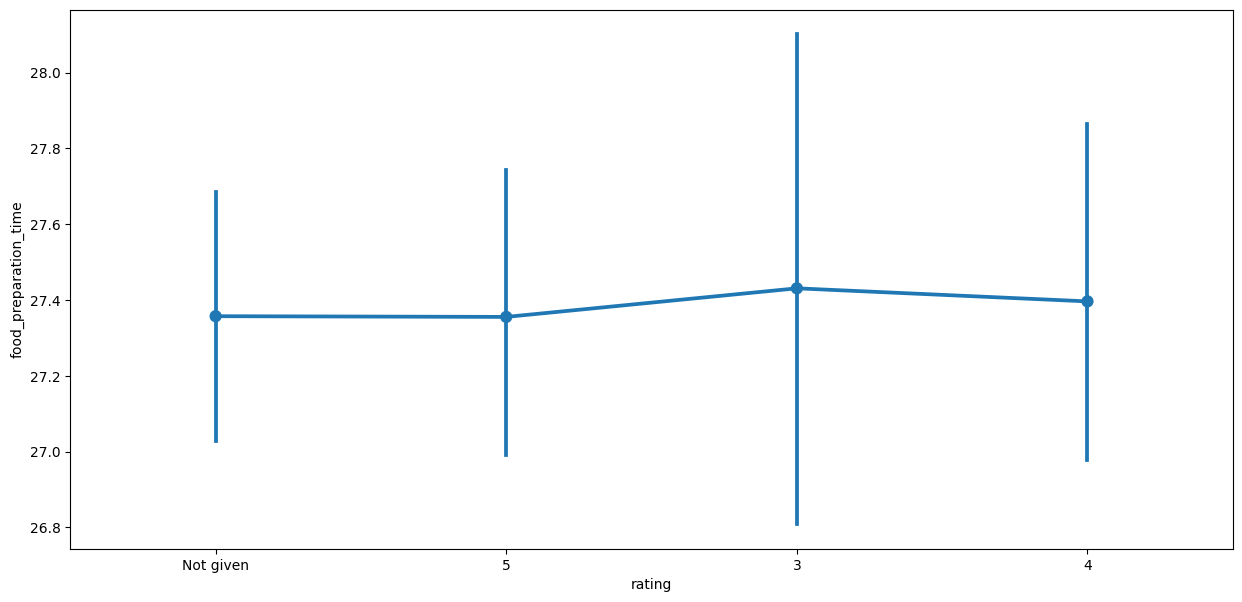

In [ ]:
# Relationship between rating and food preparation timeplt.figure(figsize=(15, 7))sns.pointplot(x = 'rating', y = 'food_preparation_time', data = df)plt.show()

The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer.

In [ ]:
# filter to segregate rated restaurantsdf_rated=df[df['rating'] != 'Not given'].copy() # creating new dataframe dropping not rated columnsdf_rated['rating']=df_rated['rating'].astype('int') #converting datatype of rating to intdf_rating_count=df_rated.groupby(['restaurant_name'])['rating'].count().sort_values(ascending = False).reset_index()df_rating_count.head(5)

,restaurant_name,rating
0,Shake Shack,133
1,The Meatball Shop,84
2,Blue Ribbon Sushi,73
3,Blue Ribbon Fried Chicken,64
4,RedFarm Broadway,41


In [ ]:
df2 = df[['restaurant_name','rating']][df['rating']!= 0].groupby('restaurant_name').mean()> 4

<ipython-input-32-05dc1ad07230>:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.  df2 = df[['restaurant_name','rating']][df['rating']!= 0].groupby('restaurant_name').mean()> 4

In [ ]:
rest_names = df_rating_count[df_rating_count['rating'] > 50]['restaurant_name']rest_names.head()

0                  Shake Shack1            The Meatball Shop2            Blue Ribbon Sushi3    Blue Ribbon Fried ChickenName: restaurant_name, dtype: object

In [ ]:
df_mean_4=df_rated[df_rated['restaurant_name'].isin(rest_names)].copy()df_mean_4.groupby(['restaurant_name'])['rating'].mean().sort_values(ascending = False).reset_index().dropna()

,restaurant_name,rating
0,The Meatball Shop,4.512
1,Blue Ribbon Fried Chicken,4.328
2,Shake Shack,4.278
3,Blue Ribbon Sushi,4.219


Observations: The four restaurants fulfilling the required criteria is¶The Meatball shopBlue Ribbon Fried ChickenShake ShackBlue Ribbon Sushi

The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders.

In [ ]:
def compute_revenue(x):    if x > 20:        return x*0.25    elif x > 5:        return x*0.15    else:        return x*0df['Revenue'] = df['cost_of_the_order'].apply(compute_revenue)df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,Revenue
0,1477147,337525,Hangawi,Korean,30.750,Weekend,Not given,25,20,7.688
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.080,Weekend,Not given,25,23,1.812
2,1477070,66393,Cafe Habana,Mexican,12.230,Weekday,5,23,28,1.835
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.200,Weekend,3,25,15,7.300
4,1478249,76942,Dirty Bird to Go,American,11.590,Weekday,4,25,24,1.738


In [ ]:
total_revenue=df['Revenue'].sum()rounded_rev=round(total_revenue,2)print(rounded_rev)

6166.3

Net revenue generated by company for all the orders is 6166.30$.

The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.)

In [ ]:
df['Total_time']=df['food_preparation_time']+df['delivery_time']total_orders=df.shape[0]df_temp=df[df['Total_time']>60].reset_index()df_temp.shapeorders_above_60=df_temp.shape[0]orders_above_60percentage_above_60=orders_above_60/total_orders*100percentage_above_60=round(percentage_above_60,2)percentage_above_60

10.54

Observations: The percentage of orders that take more than 60minutes is 10.54%

 The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends?

In [ ]:
time_analysis=df.groupby('day_of_the_week')['delivery_time'].mean()time_analysis

day_of_the_weekWeekday   28.340Weekend   22.470Name: delivery_time, dtype: float64

In [ ]:
mean_diff=time_analysis[0]-time_analysis[1]mean_diff=round(mean_diff,2)mean_diff

5.87

Observations:Difference in mean of the delivery times on weekdays as compared to weekend is 5.87 minutes.

Conclusion and Recommendations

 What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.)

Conclusions:Foodhub company has potential to increase its revenue by improving some areas includind weekday sales, less popular cuisines and less popular restaurants.

Recommendations:Offering discounts on less popular cuisines to increase its sales.Running promotions for less popular restaurants.Offering discounts on weekdays to increase sales on weekdays.Ratings can impact the cuisines and restaurants.So add a survey/rating at the beginning of new order for last placed order.